In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import control as ct
from pytz import timezone

import sys

sys.path.append("../../../")

from utils.plot import (
    config_matplotlib,
    figsize,
    fig_save_and_show,
    plot_events_data,
)
from utils.optimization import (
    save_model_params_to_json,
    load_model_params_from_json,
)
from utils.data import (
    export_dataframe_to_latex,
)
from utils.sensitivity_analysis import (
    describe_param_with_uniform_distribution,
    describe_param_with_log_uniform_distribution,
    describe_param_with_triangular_distribution,
    describe_param_with_normal_distribution,
    describe_param_with_truncated_normal_distribution,
    describe_param_with_log_normal_distribution,
    wrapped_model_function,
    create_problem_spec_and_sample,
    plot_sampled_distribuitions,
    evaluate_problem,
    analyze_time_step,
    analyze_problem,
    sobol_sensitivity_analysis_from_model_params_to_outputs,
    plot_sensitivity_analysis,
    plot_sensitivity_analysis_heatmaps,
    get_region_mean,
    plot_sensitivity_analysis_bars,
)
from utils.models import eval_poly, lut_interp

import warnings

warnings.filterwarnings("ignore")

config_matplotlib()
latex_img_path = "/home/joaoantoniocardoso/workspace_TCC/repo/thesis/assets/generated/"
latex_tex_path = "/home/joaoantoniocardoso/workspace_TCC/repo/thesis/tex/generated/"

# Sensitivity Analysis


In [2]:
from model import Battery as Battery

Battery.build({})

<NonlinearIOSystem battery: ['batt_i'] -> ['batt_v', 'batt_z', 'batt_ocv']>

In [3]:
batt_name = "D35"
cell_amps_hour = 48
series_cells = 3
parallel_cells = 1
cell_voltage = 12
nominal_Q = parallel_cells * cell_amps_hour  # Capacity, in Amper-hour
initial_SOC = 1.1
nominal_voltage = series_cells * cell_voltage
ocv_params = load_model_params_from_json("battery_ocv_params.json")
batt_k_V_OC_coeffs = ocv_params["batt_k_V_OC_coeffs"]
# batt_ocv_lut = ocv_params['batt_ocv_lut']

battery_params = {
    "batt_N_S": series_cells,
    "batt_Q": cell_amps_hour * 3600,
    "batt_eta": 1,
    "batt_R_0": 3e-3,
    "batt_R_1": 10e-2,
    "batt_C_1": 5e3,
    "batt_R_2": 10e-2,
    "batt_C_2": 5e6,
    "batt_k_V_OC_coeffs": batt_k_V_OC_coeffs,
}

model_params = battery_params
model_params

{'batt_N_S': 3,
 'batt_Q': 172800,
 'batt_eta': 1,
 'batt_R_0': 0.003,
 'batt_R_1': 0.1,
 'batt_C_1': 5000.0,
 'batt_R_2': 0.1,
 'batt_C_2': 5000000.0,
 'batt_k_V_OC_coeffs': array([10.78645833,  3.58638935, -3.07530114,  1.61637218])}

In [4]:
def _estimate_open_circuit_voltage(params, batt_z):
    if "batt_ocv_lut" in params:
        return float(lut_interp(params["batt_ocv_lut"], batt_z))
    if "batt_k_V_OC_coeffs" in params:
        coeffs = params["batt_k_V_OC_coeffs"]
        try:
            return float(lut_interp(coeffs, batt_z))
        except Exception:
            return float(eval_poly(coeffs, batt_z))
    return 0.0


def model_function(T, U, X0, **params):
    return ct.input_output_response(
        Battery.build(params=params),
        T=T,
        U=U,
        X0=X0,
        solve_ivp_method="Radau",
    ).to_pandas()


def battery_sensitivity_analysis_step_response(
    params_description: dict,
    current_step: float,
    samples: int,
    nprocs: int,
    do_plot=True,
):
    model_class = Battery
    model_tmp = model_class.build(model_params)

    T = np.linspace(0, 200, 201, endpoint=True)

    U = np.empty([model_tmp.ninputs, len(T)]) * np.nan
    U[model_tmp.input_labels.index("batt_i")] = current_step

    batt_z_0 = 0.9
    batt_v_0 = model_params.get("batt_N_S", 1) * _estimate_open_circuit_voltage(
        model_params, batt_z_0
    )

    X0 = model_class.initial_state(
        X0={
            "batt_z": batt_z_0,
            "batt_v": batt_v_0,
        },
        U0=U[:, 0],
        params=model_params,
    )

    df_sa, problem = sobol_sensitivity_analysis_from_model_params_to_outputs(
        params_description=params_description,
        T=T,
        U=U,
        X0=X0,
        model_function=model_function,
        model_class=model_class,
        model_params=model_params,
        samples=samples,
        calc_second_order=False,
        seed=42,
        nprocs=nprocs,
    )

    df_steady_state_mean = get_region_mean(df_sa, t_start=180, t_end=200)

    export_dataframe_to_latex(
        filename=f"{latex_tex_path}/PNGV_2rc_sensitivity_analysis_{current_step}.tex",
        label=f"table:PNGV_2rc_sensitivity_analysis_{current_step}",
        caption="Índices de Sobol em regime permanente",
        df_steady_state_mean=df_steady_state_mean,
    )

    if do_plot:
        display(df_steady_state_mean)

        fig_save_and_show(
            filename=f"{latex_img_path}/PNGV_2rc_sensitivity_analysis_distributions.pdf",
            save_title="Distribuição dos valores para cada fator",
            show_title="Distribution of the values for each factor",
            fig=plot_sampled_distribuitions(problem),
            ncols=3,
        )

        for output in df_sa["output"].unique():
            fig_save_and_show(
                filename=f"{latex_img_path}/PNGV_2rc_sensitivity_analysis_{current_step}_{output}.pdf",
                save_title=f"Índices de Sobol para a saída {output} durante o tempo, com degrau de {current_step} [A], com {samples} amostras",
                show_title=f"Sobol Indices for the output {output} over time with step of {current_step} [A], with {samples} samples",
                fig=plot_sensitivity_analysis(df_sa, output=output),
                ncols=3,
            )

        for output in df_sa["output"].unique():
            fig_save_and_show(
                filename=f"{latex_img_path}/PNGV_2rc_sensitivity_analysis_heatmaps_{current_step}_{output}.pdf",
                save_title=f"Índices de Sobol para a saída {output} durante o tempo, com degrau de {current_step} [A], com {samples} amostras",
                show_title=f"Sobol Indices for the output {output} over time with step of {current_step} [A], with {samples} samples",
                fig=plot_sensitivity_analysis_heatmaps(df_sa, output=output),
                ncols=3,
            )

        for output in df_sa["output"].unique():
            fig_save_and_show(
                filename=f"{latex_img_path}/PNGV_2rc_sensitivity_analysis_bars_{current_step}_{output}.pdf",
                save_title=f"Índices de Sobol para a saída {output} em regime permanente, com degrau de {current_step} [A], com {samples} amostras",
                show_title=f"Sobol Indices for the output {output} at steady-state with step of {current_step} [A], with {samples} samples",
                fig=plot_sensitivity_analysis_bars(df_steady_state_mean, output=output),
                ncols=3,
            )

    return df_sa, problem

In [5]:
# Setting all uncertainties to be x%
u_batt_R_0 = 1 / 100
u_batt_R_1 = 1 / 100
u_batt_R_2 = 1 / 100
u_batt_C_1 = 1 / 100
u_batt_C_2 = 1 / 100
u_batt_Q = 1 / 100
u_batt_eta = 1 / 100

In [6]:
%%time

params_description = {
    'batt_Q': describe_param_with_uniform_distribution(lower=model_params['batt_Q']*(1-u_batt_Q), upper=model_params['batt_Q']*(1+u_batt_Q)),
    'batt_R_0': describe_param_with_uniform_distribution(lower=model_params['batt_R_0']*(1-u_batt_R_0), upper=model_params['batt_R_0']*(1+u_batt_R_0)),
    'batt_R_1': describe_param_with_uniform_distribution(lower=model_params['batt_R_1']*(1-u_batt_R_1), upper=model_params['batt_R_1']*(1+u_batt_R_1)),
    'batt_R_2': describe_param_with_uniform_distribution(lower=model_params['batt_R_2']*(1-u_batt_R_2), upper=model_params['batt_R_2']*(1+u_batt_R_2)),
    'batt_C_1': describe_param_with_uniform_distribution(lower=model_params['batt_C_1']*(1-u_batt_C_1), upper=model_params['batt_C_1']*(1+u_batt_C_1)),
    'batt_C_2': describe_param_with_uniform_distribution(lower=model_params['batt_C_2']*(1-u_batt_C_2), upper=model_params['batt_C_2']*(1+u_batt_C_2)),
    'batt_eta': describe_param_with_uniform_distribution(lower=model_params['batt_eta']*(1-u_batt_eta), upper=model_params['batt_eta']*(1+u_batt_eta)),
}

CPU times: user 4 μs, sys: 2 μs, total: 6 μs
Wall time: 8.82 μs


pool
chain


value          conf
output   factor   metric                            
batt_ocv batt_eta S1      4.999751e-01  1.251849e-02
                  ST      4.999887e-01  9.174813e-03
         batt_R_2 S1     -1.411090e-16  3.427345e-15
                  ST      2.530073e-26  1.331651e-27
         batt_R_1 S1     -6.343284e-16  3.470888e-15
                  ST      2.525667e-26  1.350419e-27
         batt_R_0 S1      0.000000e+00  0.000000e+00
                  ST      0.000000e+00  0.000000e+00
         batt_Q   S1      5.000148e-01  1.194734e-02
                  ST      5.000284e-01  1.024209e-02
         batt_C_2 S1      4.461352e-16  3.516419e-15
                  ST      2.527350e-26  1.270034e-27
         batt_C_1 S1     -8.529906e-16  3.433409e-15
                  ST      2.502744e-26  1.324452e-27
batt_v   batt_eta S1      6.658983e-03  1.816189e-03
                  ST      6.659170e-03  1.520174e-04
         batt_R_2 S1      4.512628e-07  1.415018e-05
                  ST      4.513196e-07  1.074460e-08
         batt_R_1 S1      5.000360e-01  1.386714e-02
                  ST      5.000542e-01  1.071361e-02
         batt_R_0 S1      1.748881e-02  2.896015e-03
                  ST      1.748881e-02  4.230108e-04
         batt_Q   S1      6.659521e-03  1.751442e-03
                  ST      6.659699e-03  1.482664e-04
         batt_C_2 S1      1.001418e-06  2.102040e-05
                  ST      1.002428e-06  2.244997e-08
         batt_C_1 S1      4.691376e-01  1.366584e-02
                  ST      4.691549e-01  1.007809e-02
batt_z   batt_eta S1      4.999717e-01  1.251910e-02
                  ST      4.999883e-01  9.174490e-03
         batt_R_2 S1     -2.206085e-16  1.299356e-15
                  ST      3.320201e-27  8.410522e-29
         batt_R_1 S1     -1.883028e-16  1.245647e-15
                  ST      3.314903e-27  8.337030e-29
         batt_R_0 S1      0.000000e+00  0.000000e+00
                  ST      0.000000e+00  0.000000e+00
         batt_Q   S1      5.000153e-01  1.194842e-02
                  ST      5.000320e-01  1.024078e-02
         batt_C_2 S1      4.240120e-16  1.196384e-15
                  ST      3.302166e-27  8.209092e-29
         batt_C_1 S1     -7.098250e-16  1.148519e-15
                  ST      3.275378e-27  8.061477e-29

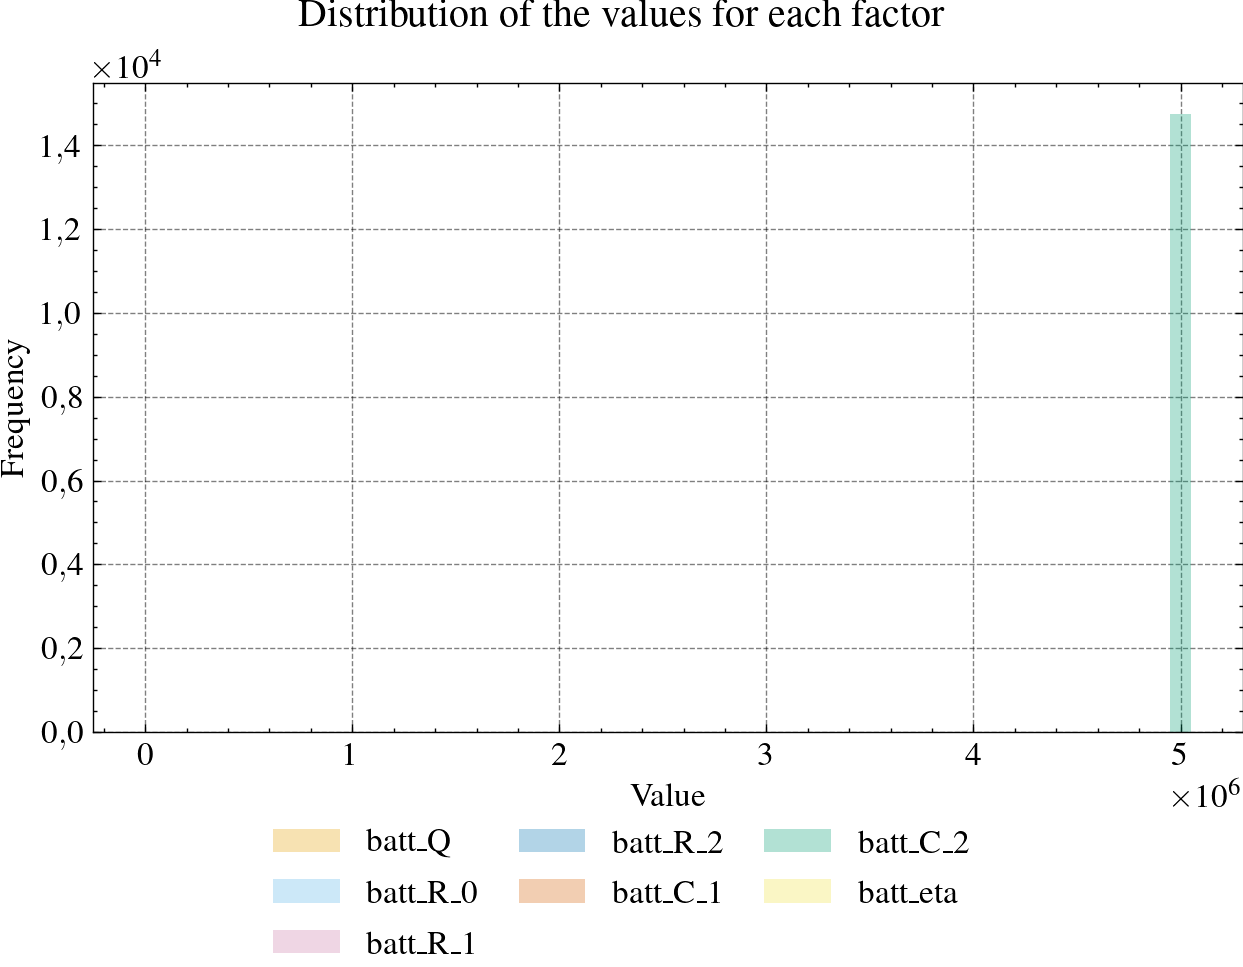

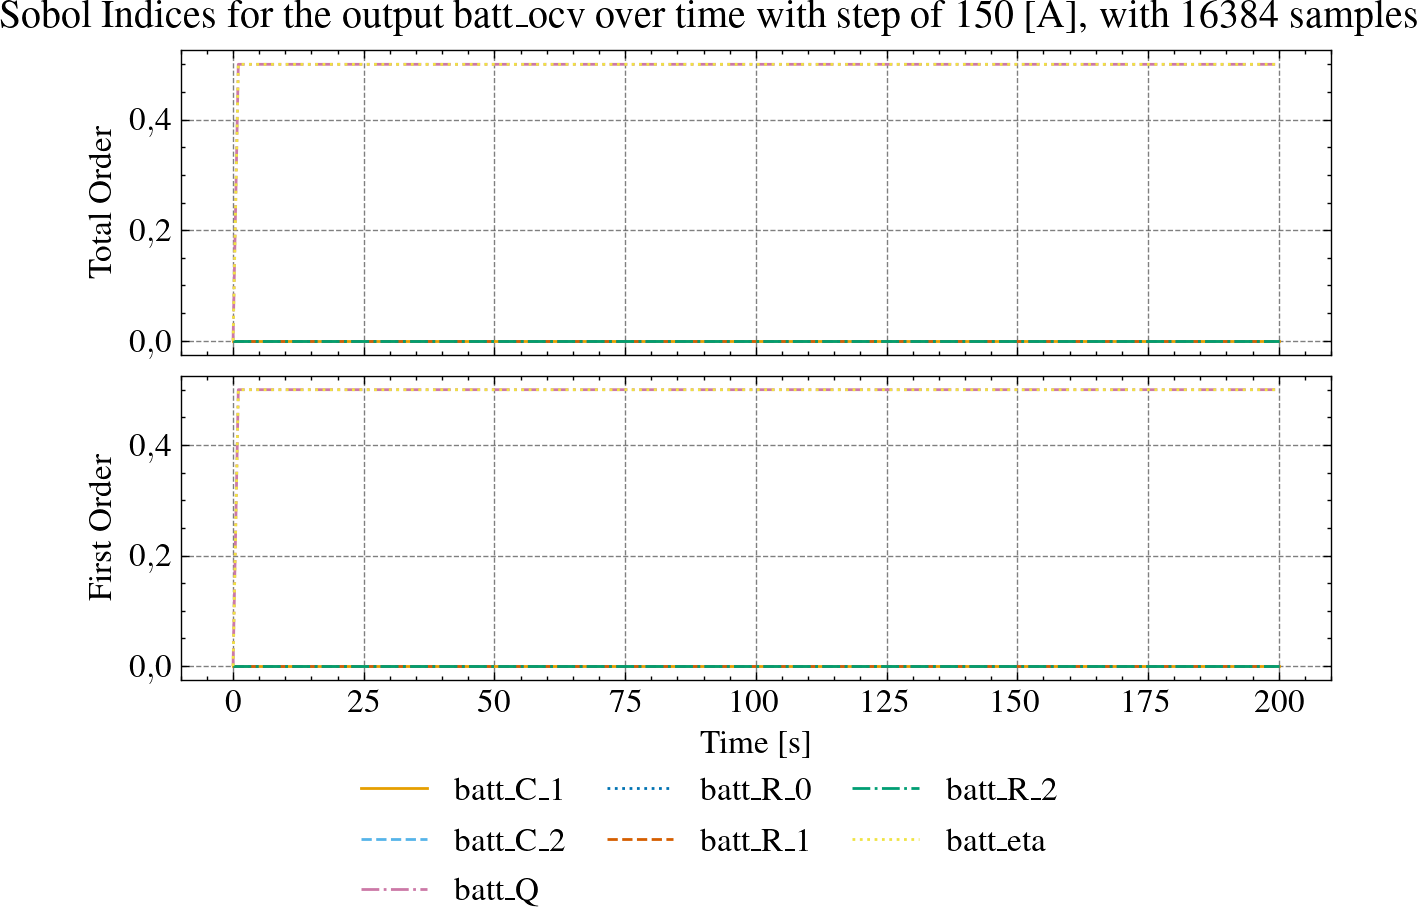

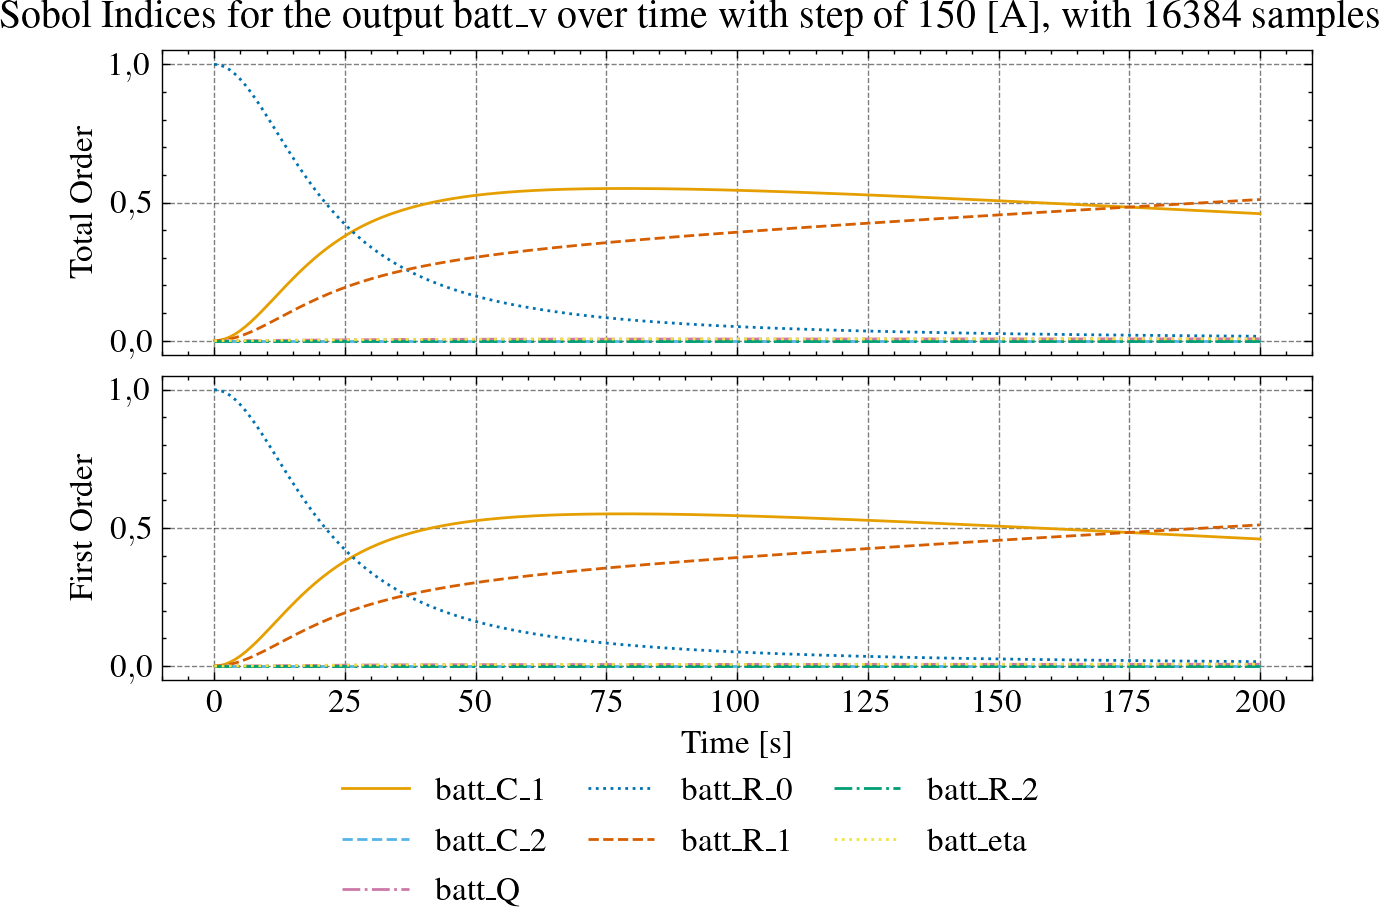

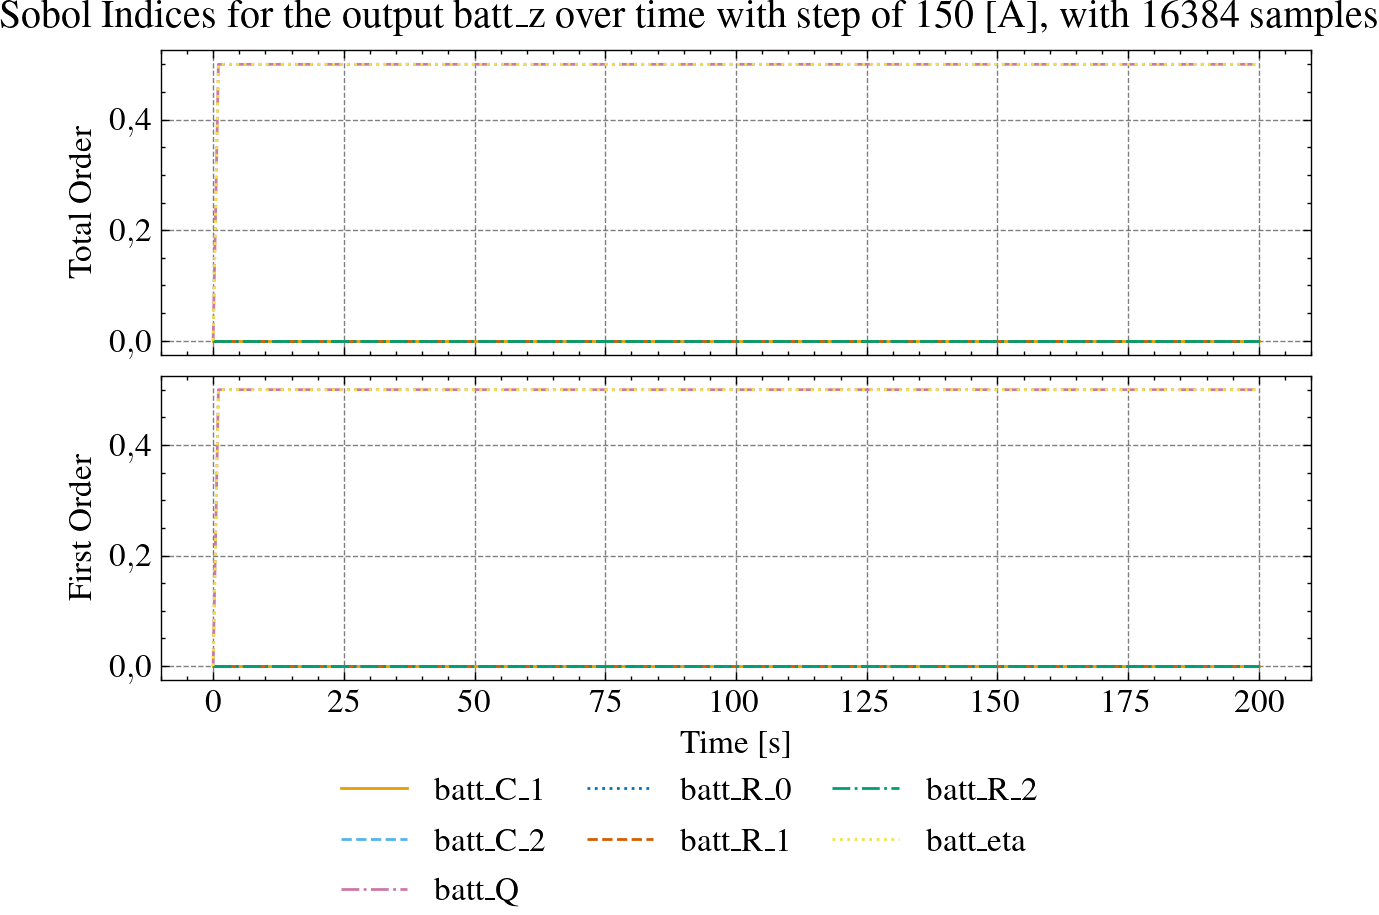

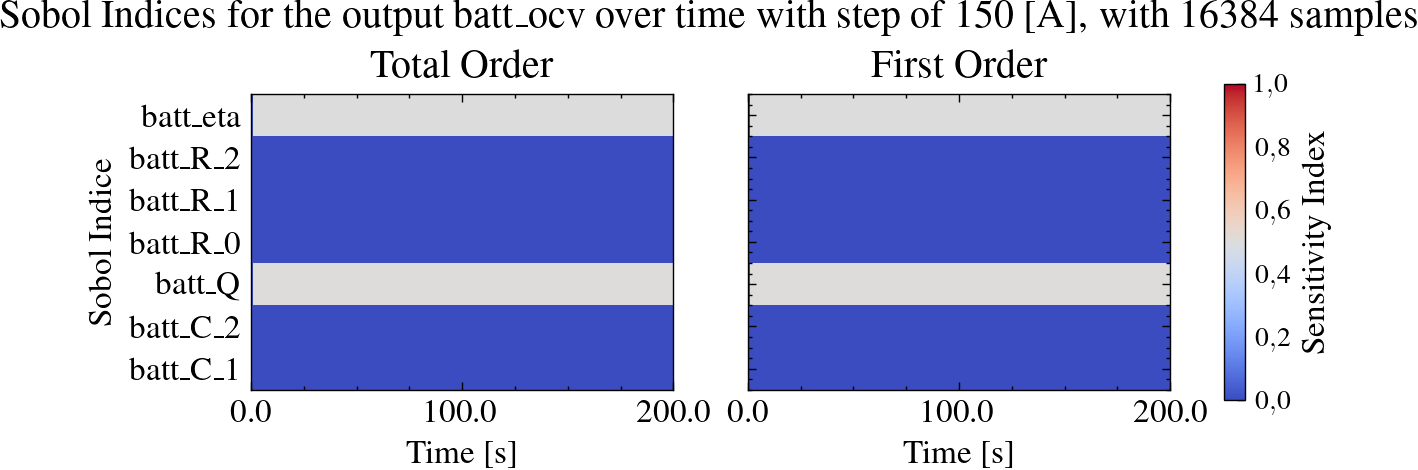

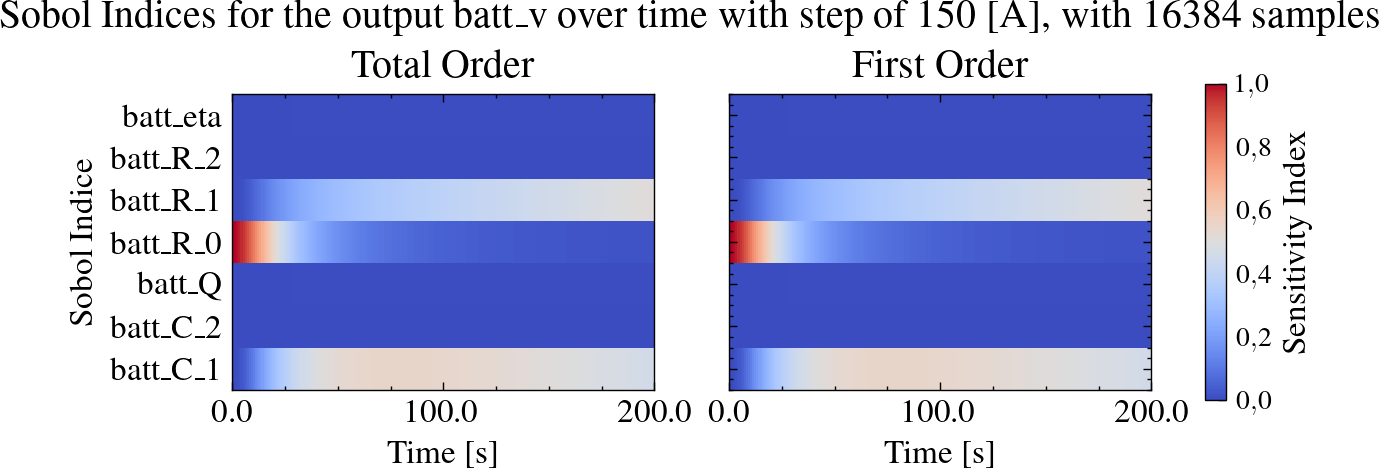

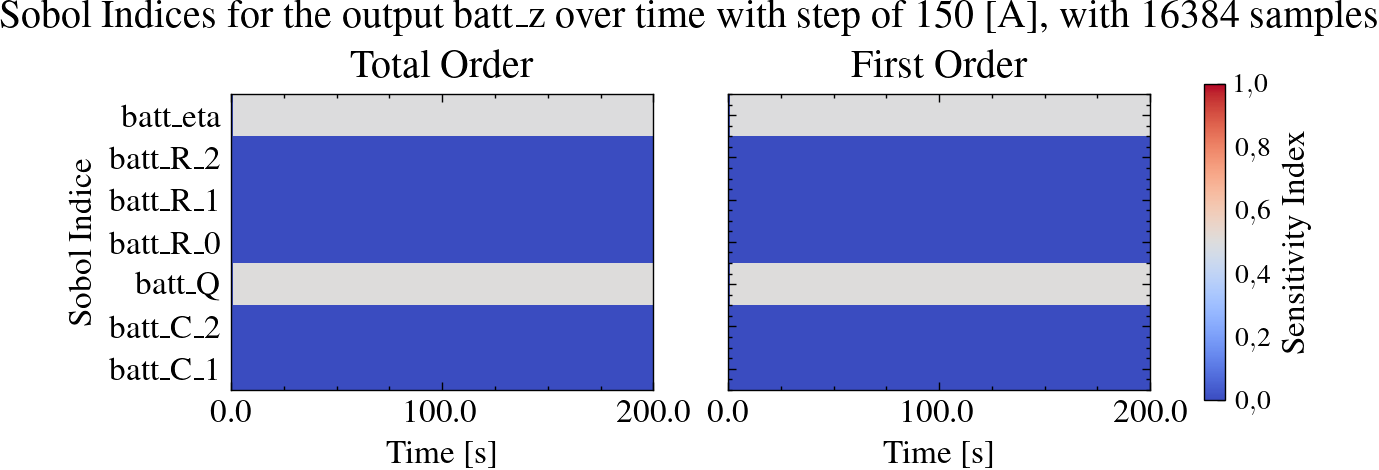

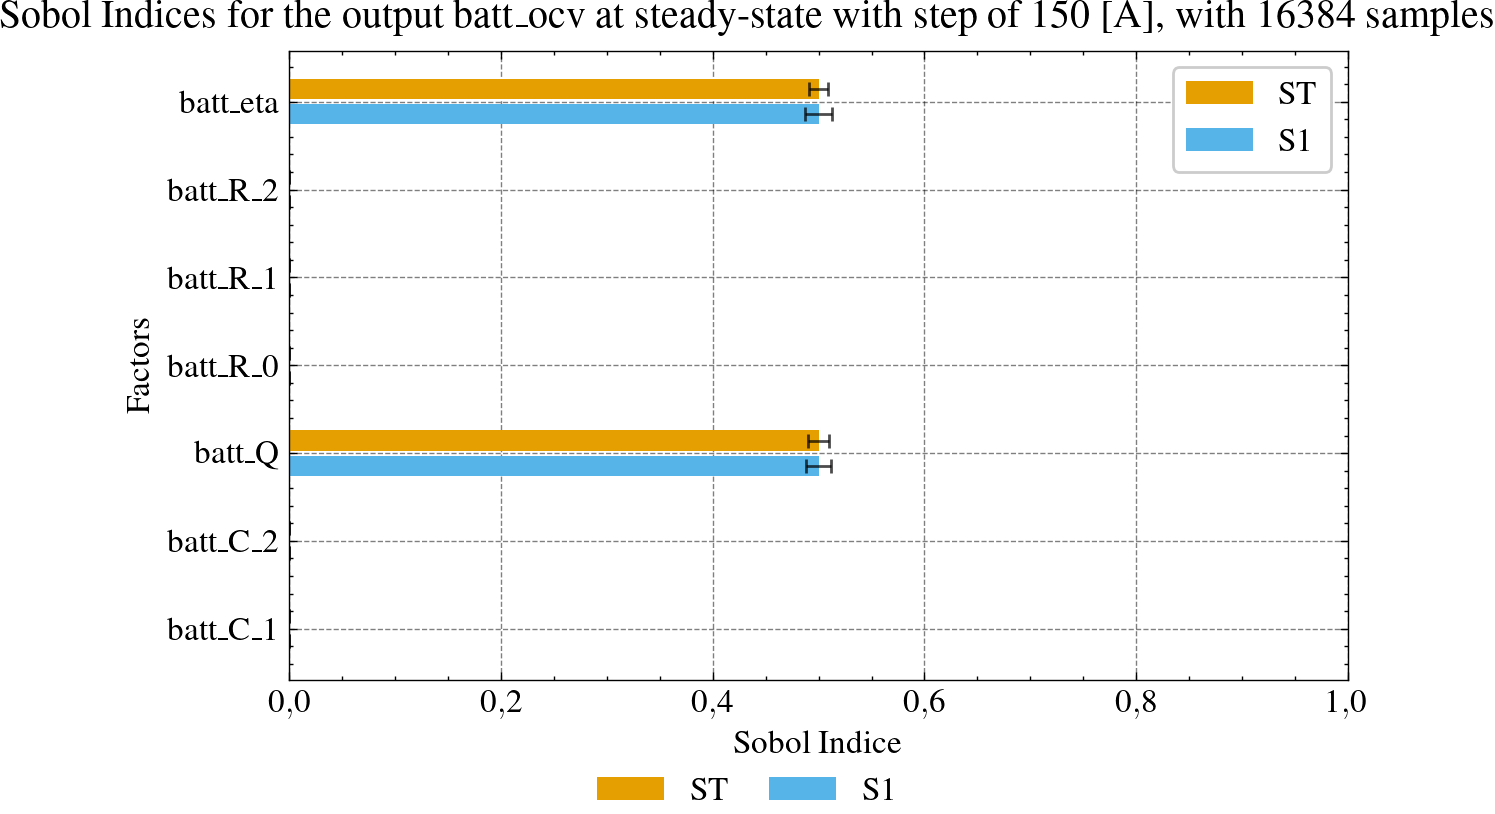

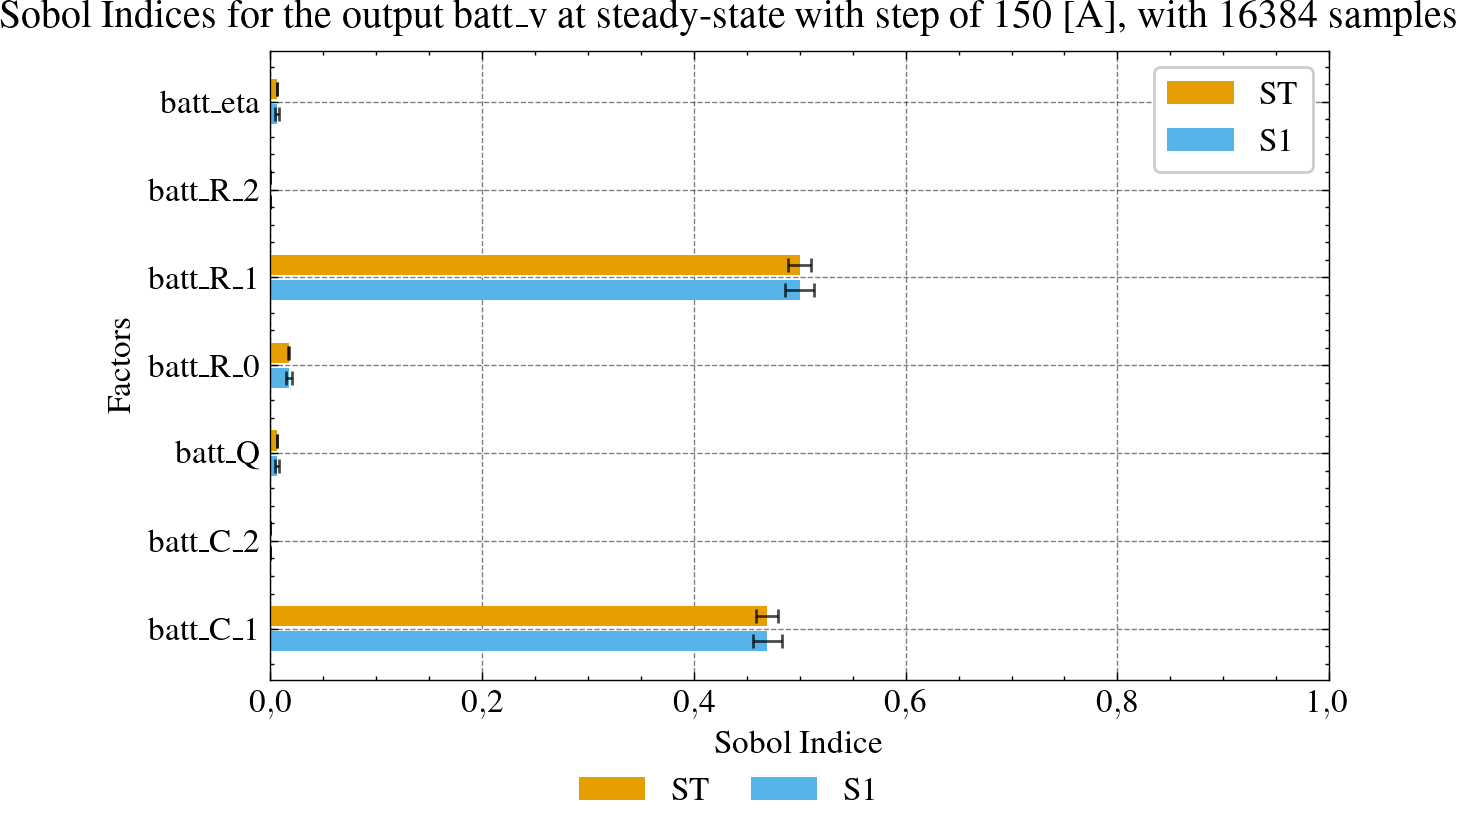

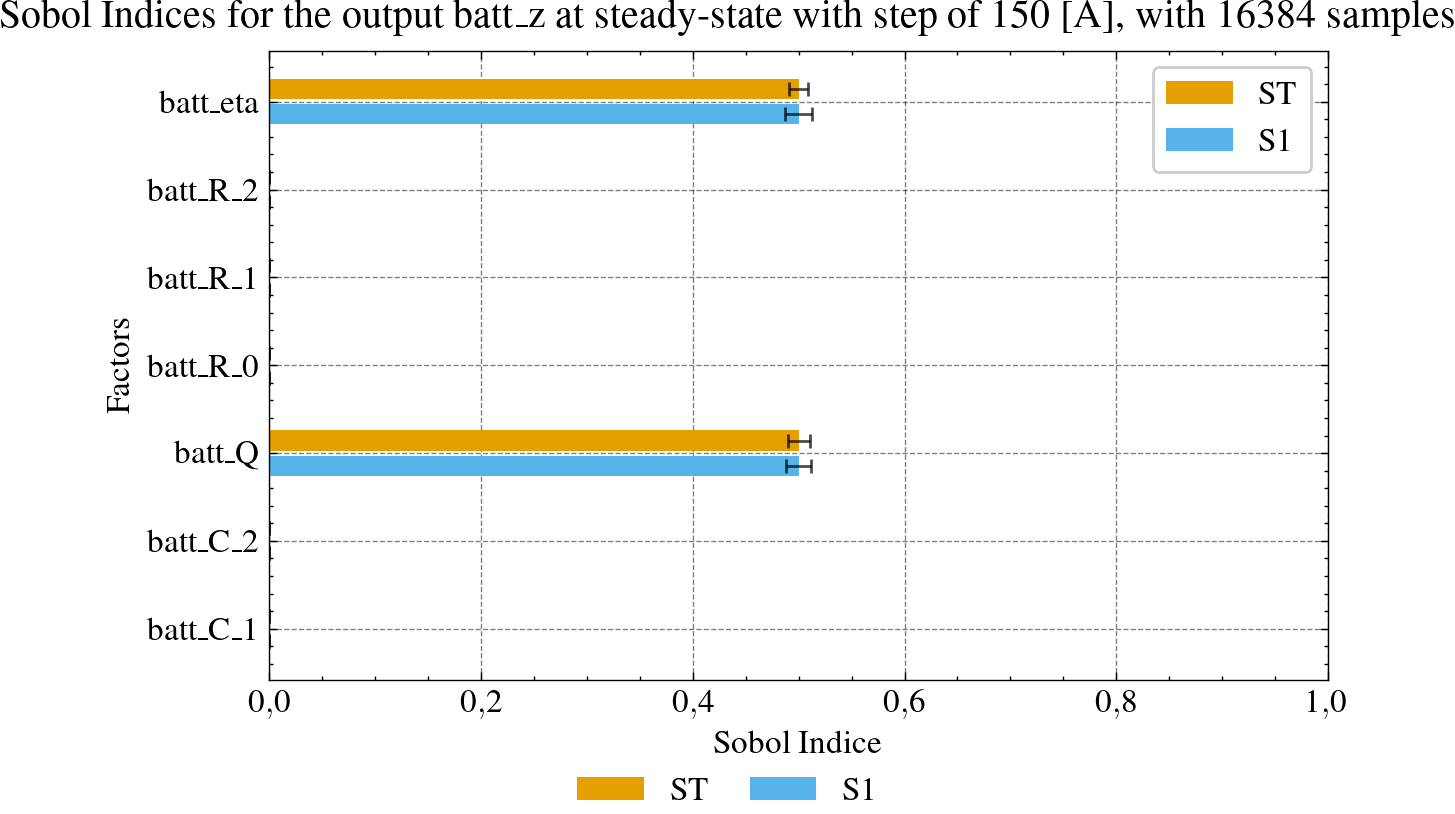

In [7]:
df_sa_discharge, problem_discharge = battery_sensitivity_analysis_step_response(
    params_description=params_description,
    current_step=150,
    samples=2**14,
    nprocs=2,
    do_plot=True,
)

pool
chain


value          conf
output   factor   metric                            
batt_ocv batt_eta S1      4.999700e-01  1.251940e-02
                  ST      4.999882e-01  9.174344e-03
         batt_R_2 S1     -7.902113e-15  1.340308e-14
                  ST      4.054372e-25  2.121281e-26
         batt_R_1 S1      8.365183e-17  1.353953e-14
                  ST      3.994583e-25  2.074620e-26
         batt_R_0 S1      0.000000e+00  0.000000e+00
                  ST      0.000000e+00  0.000000e+00
         batt_Q   S1      5.000156e-01  1.194895e-02
                  ST      5.000338e-01  1.024015e-02
         batt_C_2 S1     -3.175406e-15  1.394329e-14
                  ST      4.070050e-25  2.196886e-26
         batt_C_1 S1      1.237559e-16  1.348507e-14
                  ST      4.010776e-25  2.161046e-26
batt_v   batt_eta S1      5.826541e-04  5.891087e-04
                  ST      5.826751e-04  1.235904e-05
         batt_R_2 S1      7.144884e-07  2.028714e-05
                  ST      7.143899e-07  1.725874e-08
         batt_R_1 S1      2.687826e-01  1.084516e-02
                  ST      2.687850e-01  6.035472e-03
         batt_R_0 S1      1.014519e-03  5.926636e-04
                  ST      1.014519e-03  2.305882e-05
         batt_Q   S1      5.827047e-04  5.339389e-04
                  ST      5.827283e-04  1.297916e-05
         batt_C_2 S1      1.558254e-06  2.671564e-05
                  ST      1.558358e-06  3.190810e-08
         batt_C_1 S1      7.290322e-01  1.654260e-02
                  ST      7.290344e-01  1.478898e-02
batt_z   batt_eta S1      4.999717e-01  1.251910e-02
                  ST      4.999883e-01  9.174490e-03
         batt_R_2 S1     -5.263662e-15  5.041857e-15
                  ST      5.559694e-26  1.337229e-27
         batt_R_1 S1     -1.540546e-15  5.072889e-15
                  ST      5.452118e-26  1.310042e-27
         batt_R_0 S1      0.000000e+00  0.000000e+00
                  ST      0.000000e+00  0.000000e+00
         batt_Q   S1      5.000153e-01  1.194842e-02
                  ST      5.000320e-01  1.024078e-02
         batt_C_2 S1     -1.027326e-15  4.896409e-15
                  ST      5.526353e-26  1.382486e-27
         batt_C_1 S1      1.692350e-16  4.767219e-15
                  ST      5.483272e-26  1.320561e-27

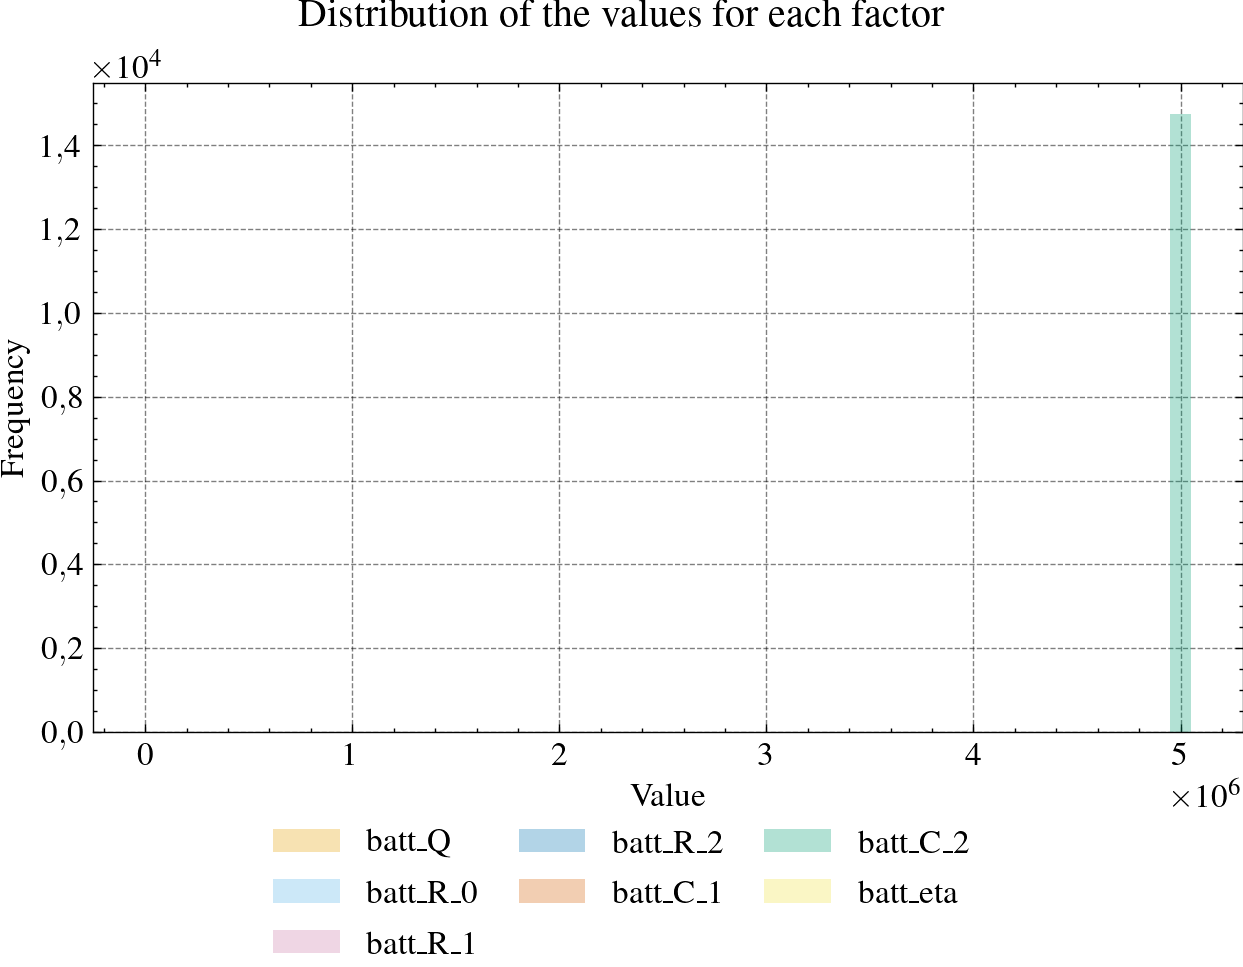

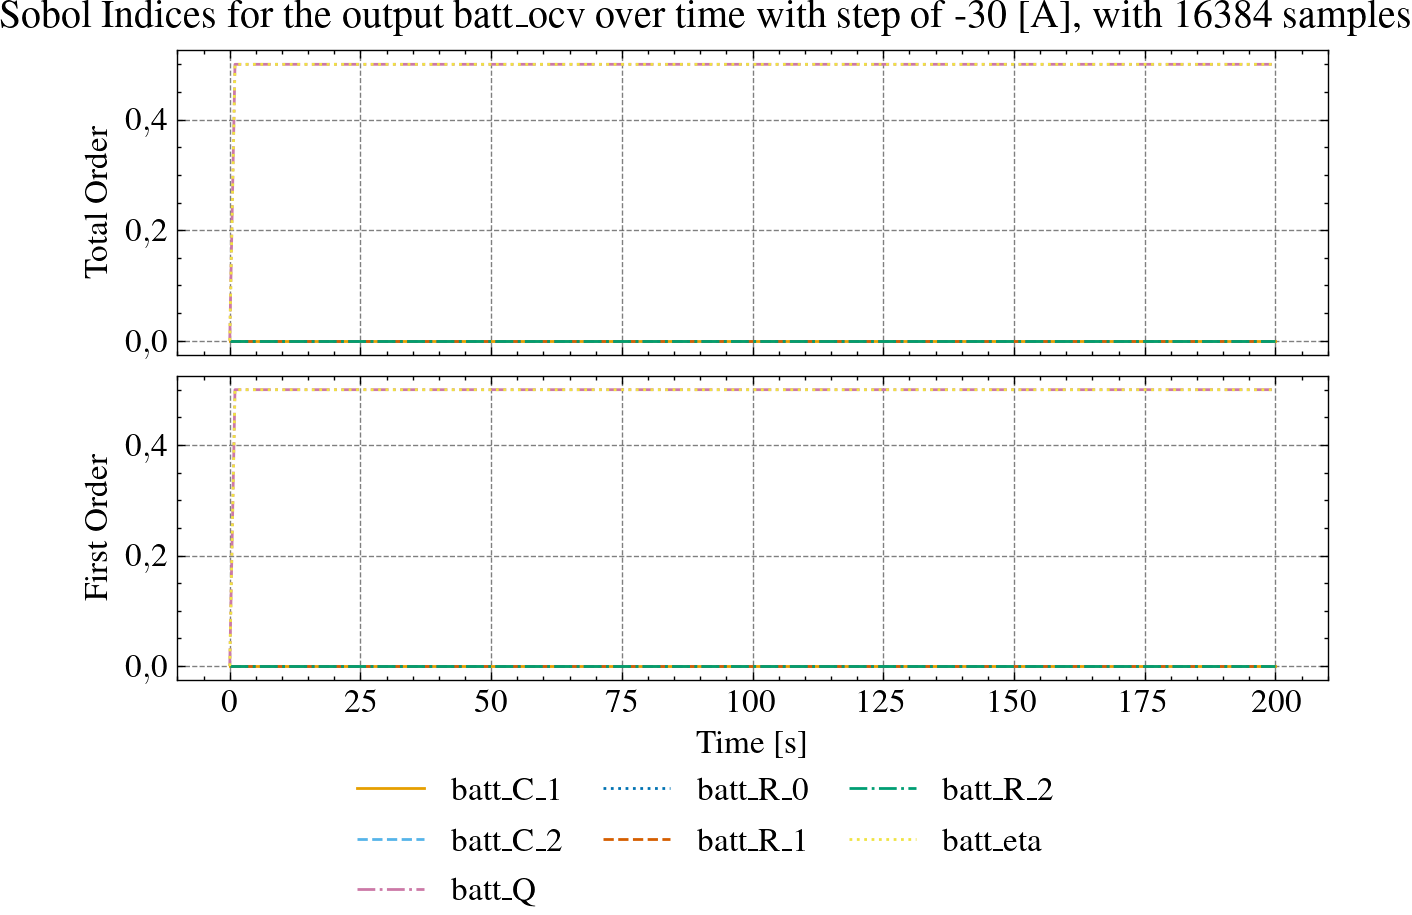

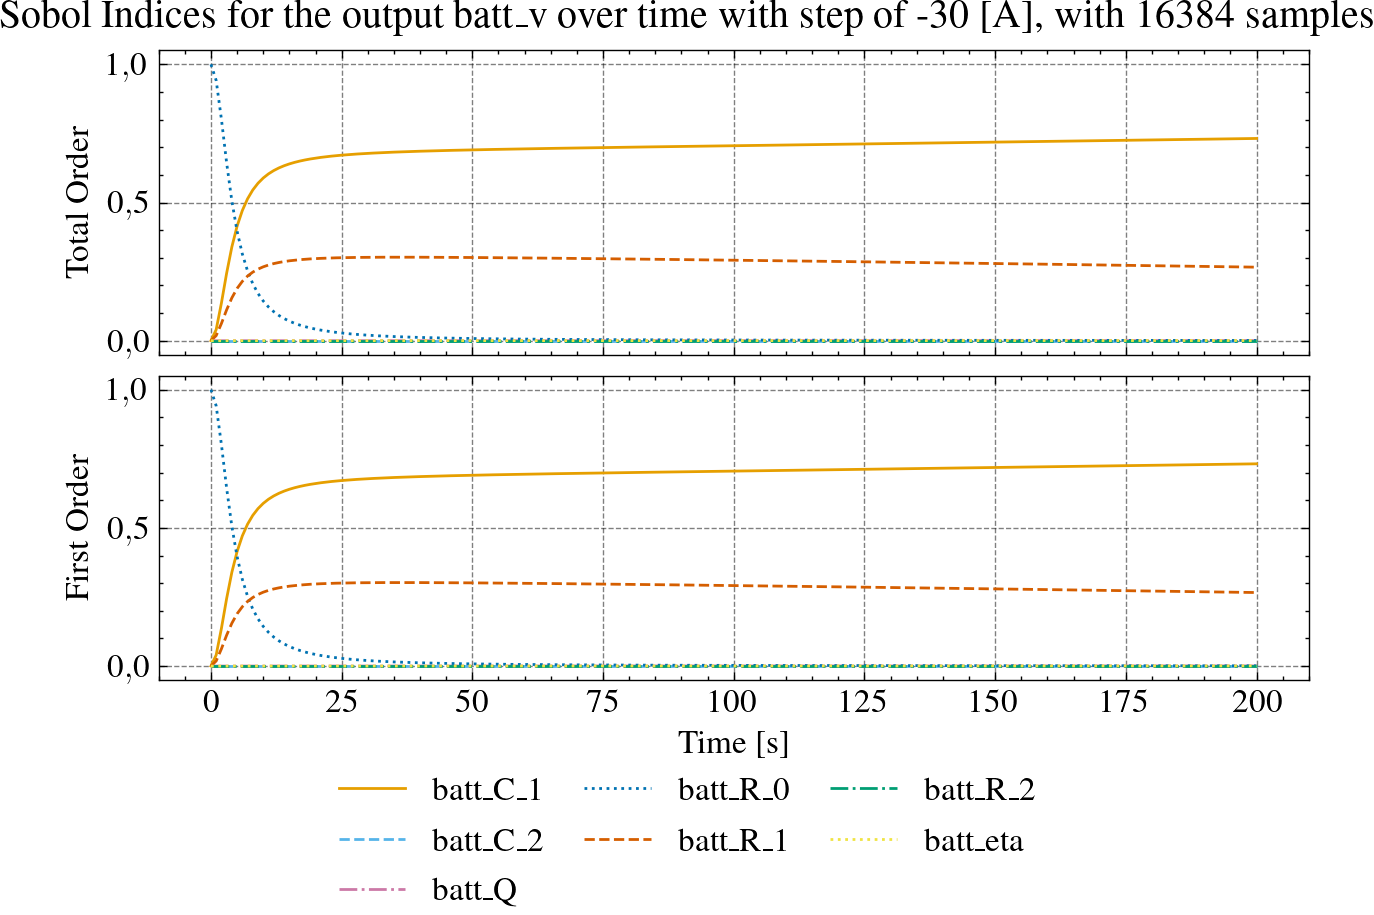

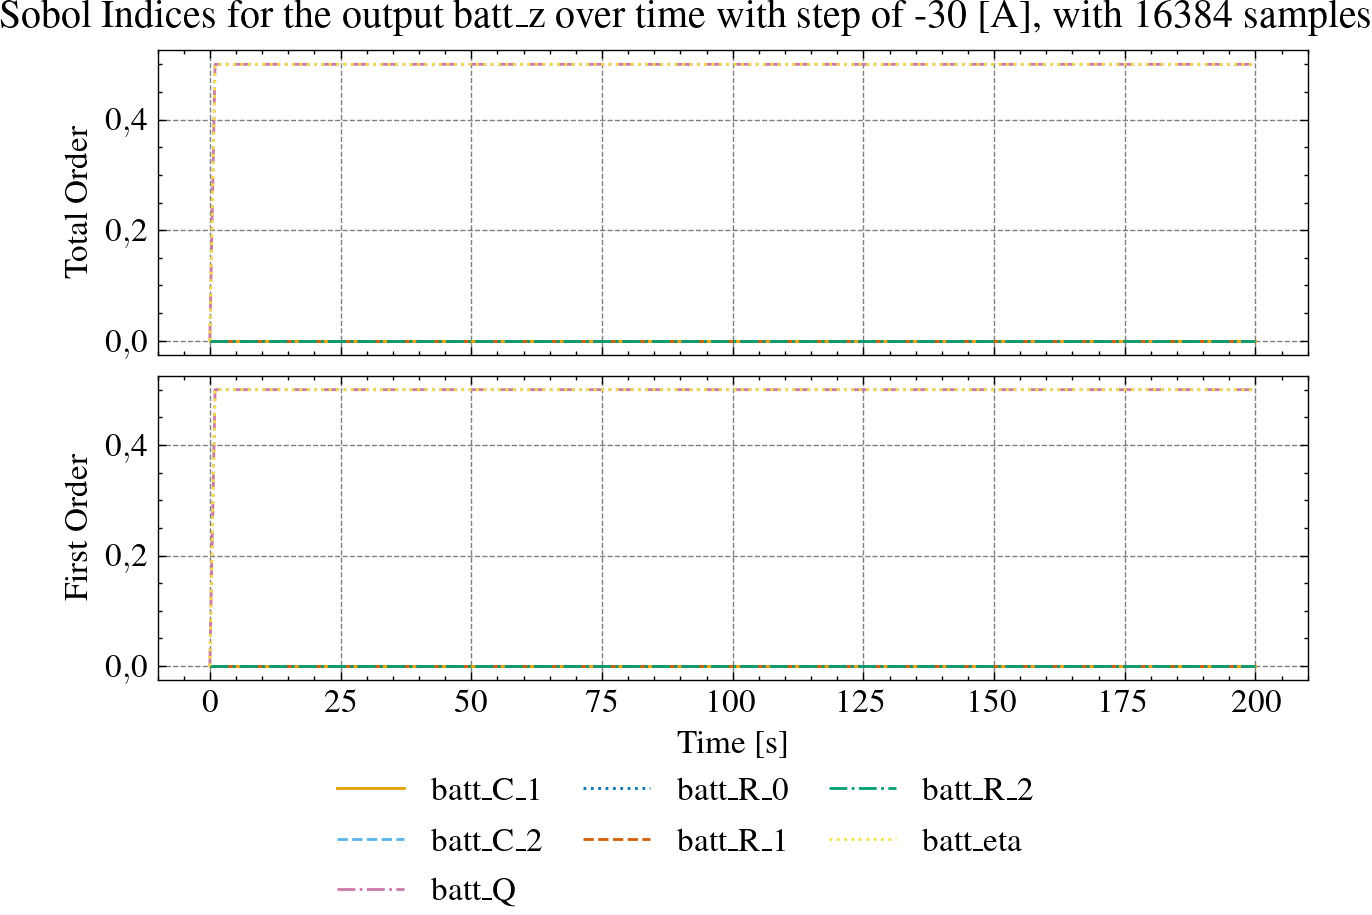

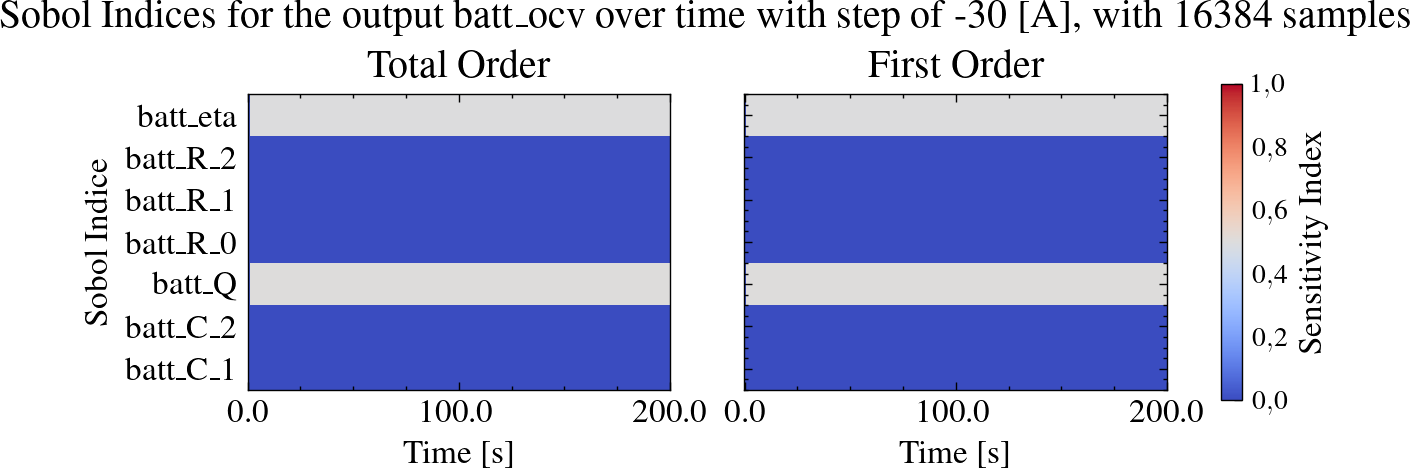

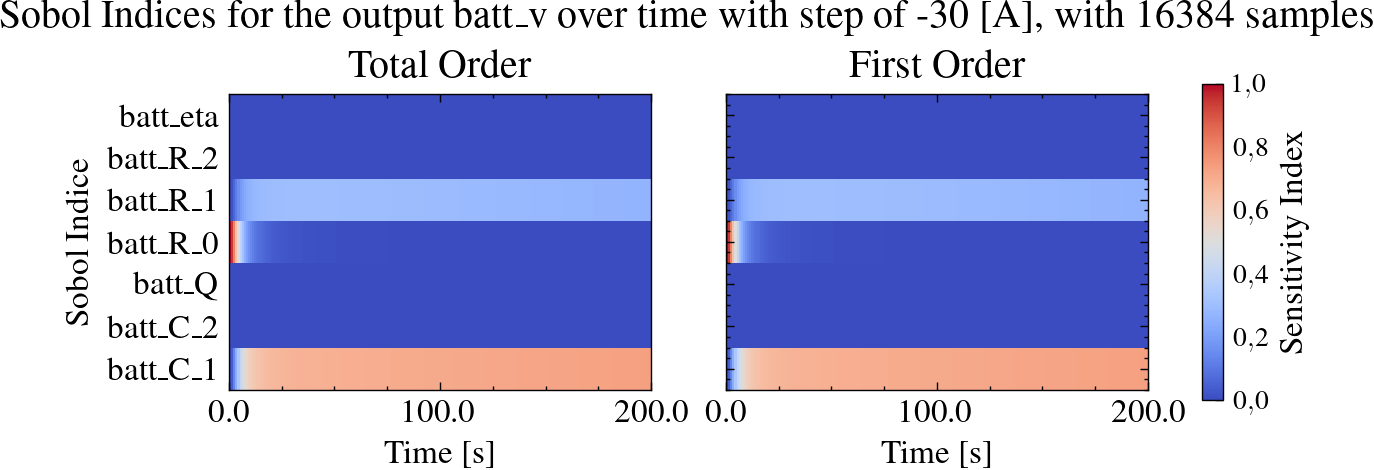

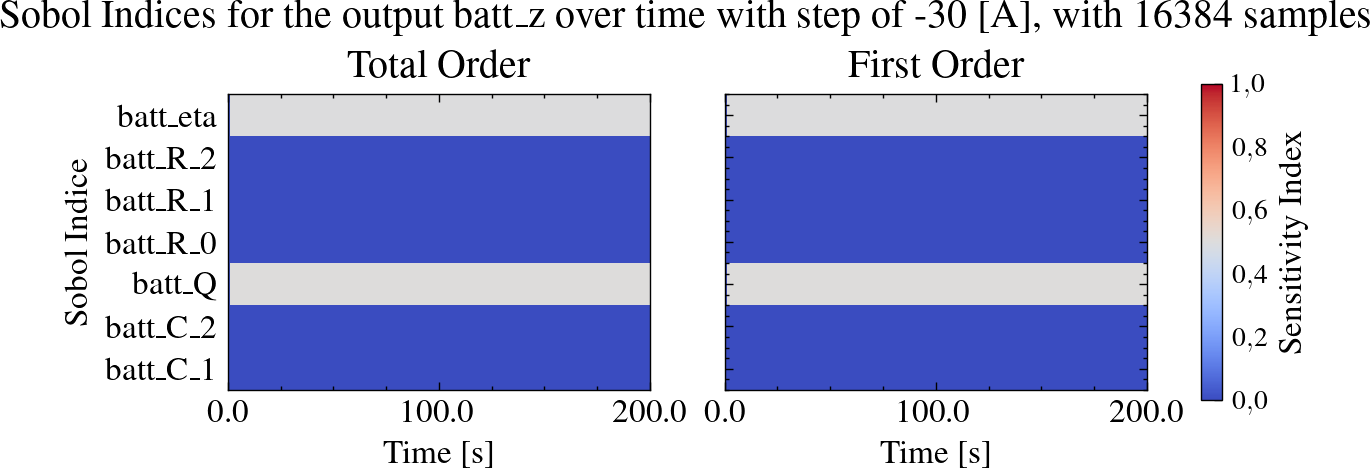

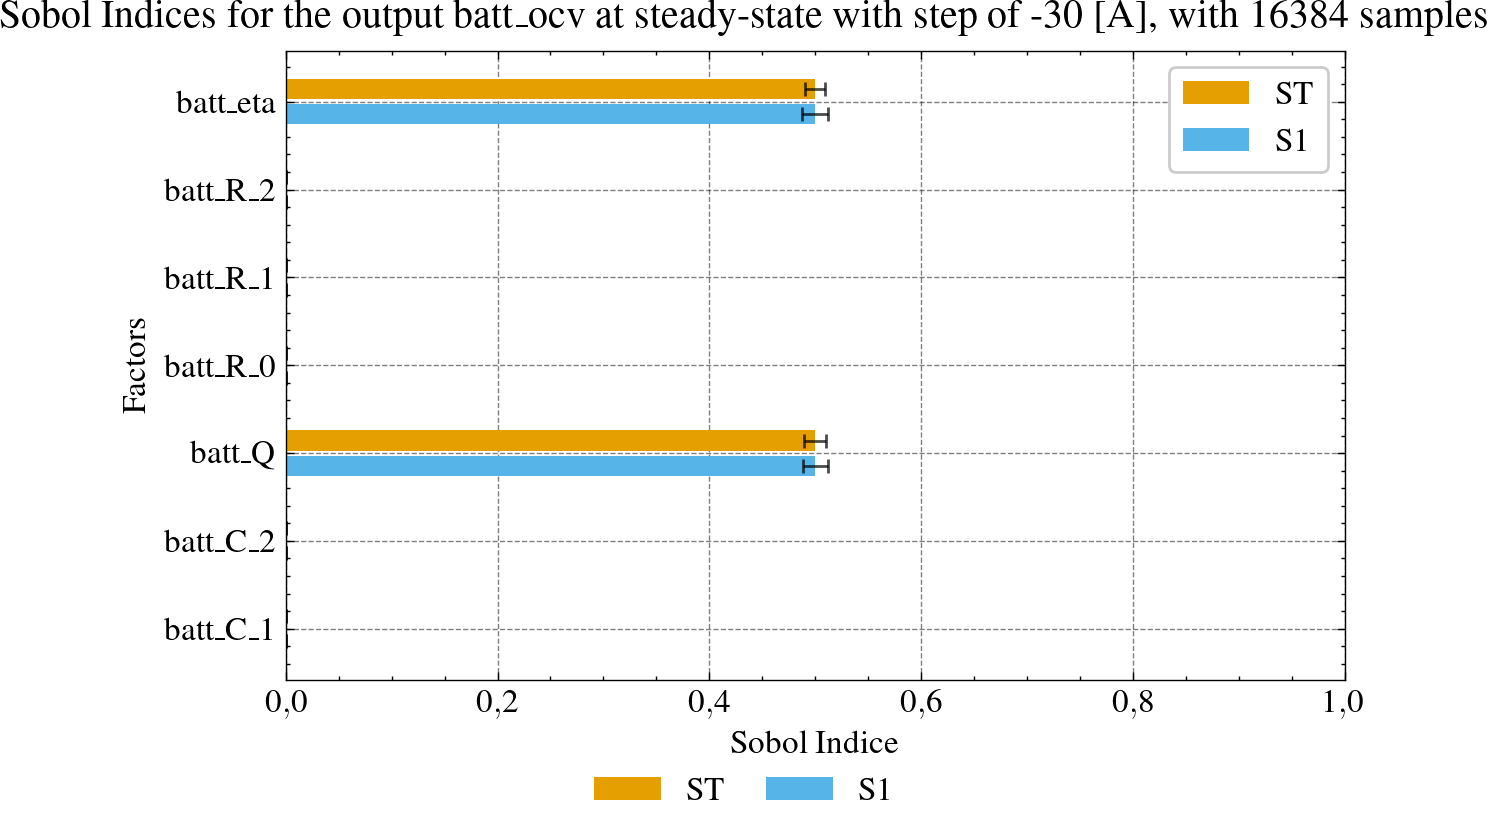

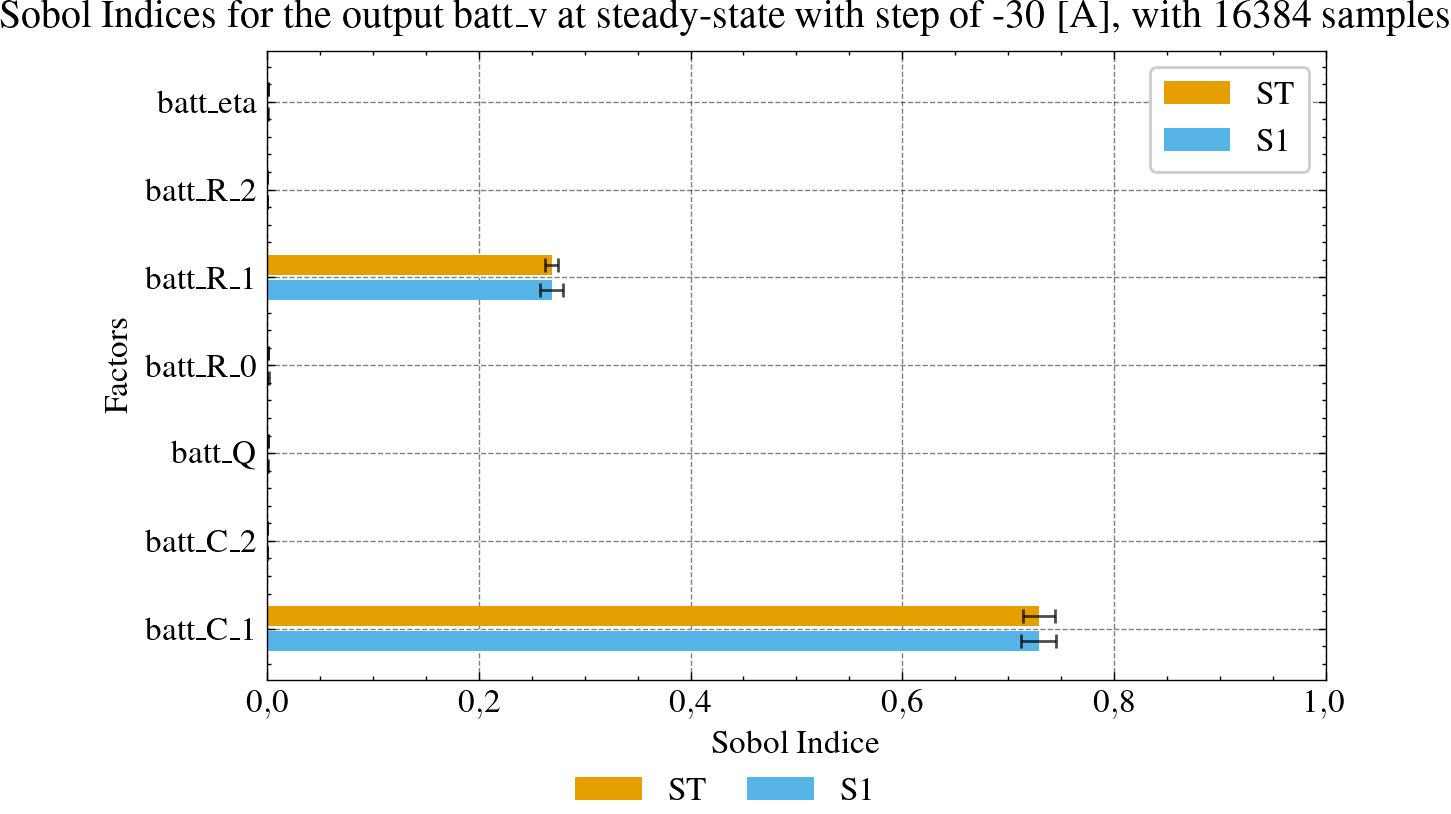

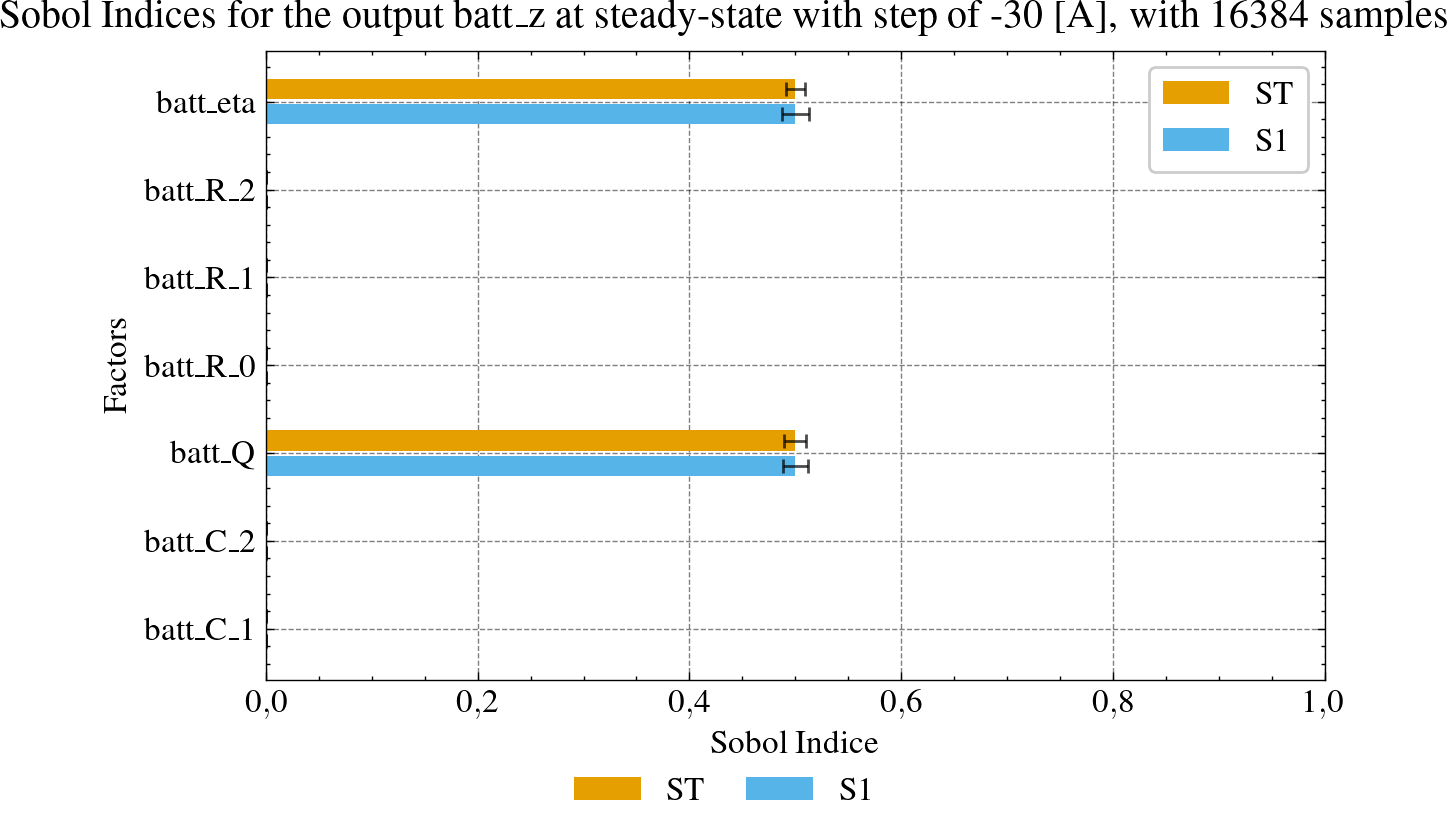

In [8]:
df_sa_charge, problem_charge = battery_sensitivity_analysis_step_response(
    params_description=params_description,
    current_step=-30,
    samples=2**14,
    nprocs=2,
    do_plot=True,
)